In [77]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
import src  
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import functools
set_seed(0) 

In [78]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [79]:
checkpoint_dir = Path("../checkpoints/mixer_tpp_20250829-192639") 
# checkpoints/mixer_tpp_20250912-125450
 # "../checkpoints/mixer_tpp_20250907-112659"
 # /checkpoints/mixer_tpp_20250825-114639 /checkpoints/rtpp_20250824-214315
 # checkpoints/mixer_tpp_20250819-143535 checkpoints/mixer_tpp_20250819-143210
 # checkpoints/rtpp_20250819-142340
checkpoint_path = checkpoint_dir / "last_model_1.pth"

## Loading a trained model
All models trained on the default versions of the catalog are stored in `{PROJECT_ROOT_DIR}/trained_models/`.

In [80]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint

check_point = torch.load(checkpoint_path,weights_only=False)
args = load_args_from_checkpoint(None, check_point)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
# model.set_attn_type("flash")
# model.set_attn_dropout(0)

model = torch.compile(model)
model.eval() 

using time scale base 0.09745454788208008 (key: tau_mean)
tau mean: 0.09745454788208008
load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'mixer_tpp', 'num_event_types': 1, 'pad_token_id': 1, 'task_type': 'tpp', 'batch_size': 32, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'step_warmup', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.8, 'dropout': 0.3, 'd_model': 64, 'mixer_model_config': {'input_dim': 1, 'dropout_prob': 0.1, 'd_model': 64, 'n_layer': 1, 'd_intermediate': 128, 'attn_layer_idx': [], 'ssm_cfg': {'layer': 'Mamba2Rotary', 'd_conv': 4, 'use_conv': False, 'rotary_emb_scale_base': 2048}, 'attn_cfg': {'layer': 'MHATime', 'num_heads': 4, 'rotary_emb_dim': 8, 'rotary_emb_scale_base': 2048, 'causal': True}, 'norm_epsilon': 1e-05, 'rms_norm': False, 

OptimizedModule(
  (_orig_mod): MixerTPP(
    (base_model): MixerModelWrapper(
      (encoder): MixerModel(
        (input_linear): Linear(in_features=1, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (layers): ModuleList(
          (0): Block(
            (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mixer): Mamba2Rotary(
              (in_proj): Linear(in_features=64, out_features=514, bias=False)
              (act): SiLU()
              (norm): RMSNorm()
              (out_proj): Linear(in_features=128, out_features=64, bias=False)
              (rotary_emb): RotaryEmbeddingTime()
            )
            (dropout): Dropout(p=0.1, inplace=False)
            (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mlp): GatedMLP(
              (fc1): Linear(in_features=64, out_features=256, bias=False)
              (fc2): Linear(in_features=128, out_features=64, bias=False)
            )
          

## Loading the catalog
We load the catalog like in the previous notebook.

In [81]:
# args.dataset = "ChinaArray" 
catalog_ds_class = catalog.Catalog.by_name(f"{args.dataset}-Standard")
catalog_ds = catalog_ds_class(root_dir=f'../data/{args.dataset}/raw',catalog_file=None)

Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/SCEDC/raw.


In [82]:
catalog_ds.full_sequence

Sequence(
  inter_times: [125669],
  arrival_times: [125668],
  t_start: 0.0,
  t_end: 14243.999,
  t_nll_start: 0.0,
  mag: [125668]
)

In [83]:
window_size = 300
stride = 10
arrival_times = catalog_ds.full_sequence.arrival_times
max_time = arrival_times.max().item()
window_starts = torch.arange(0, max_time - window_size + stride, stride)
counts = torch.zeros(len(window_starts), dtype=torch.int32)

for i, start in enumerate(window_starts):
    end = start + window_size
    mask = (arrival_times >= start) & (arrival_times < end)
    counts[i] = mask.sum()

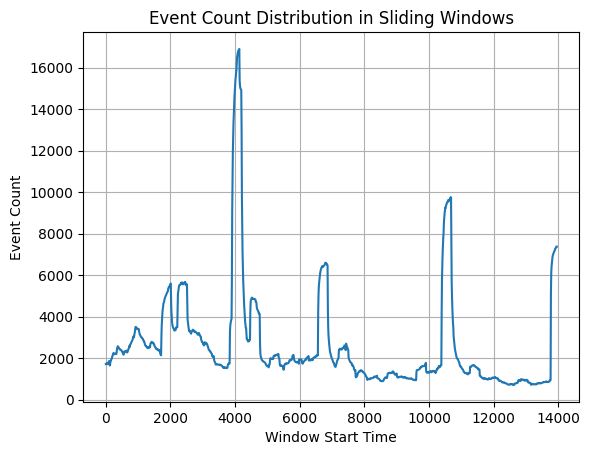

In [84]:
import matplotlib.pyplot as plt

plt.plot(window_starts, counts)
plt.xlabel('Window Start Time')
plt.ylabel('Event Count')
plt.title('Event Count Distribution in Sliding Windows')
plt.grid(True)
plt.show()

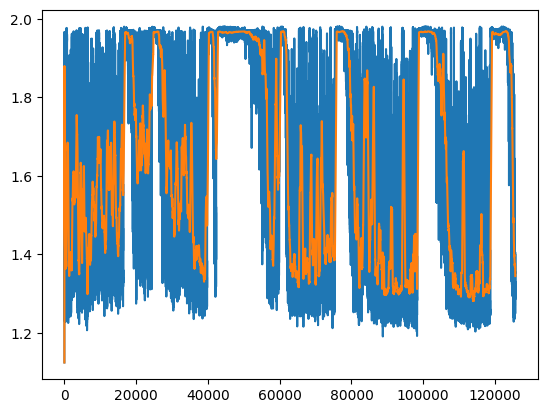

In [85]:
b_seq = model.compute_b_value(catalog_ds.full_sequence.to(device),True)
plt.plot(b_seq.squeeze().detach().cpu().numpy())
plt.savefig(checkpoint_dir/'b_pred.png')
data = b_seq.squeeze().detach().cpu().numpy()
smooth = pd.Series(data).rolling(window=500, min_periods=1).mean()
plt.plot(smooth)
plt.savefig(checkpoint_dir/'b_pred_smooth.png')

## Prepare the data

We trained the TPP model using the `train` and `val` sequences. Now we will use the unseen section of the `test` sequence (in orange) to evaluate forecasting performance of the model.

<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

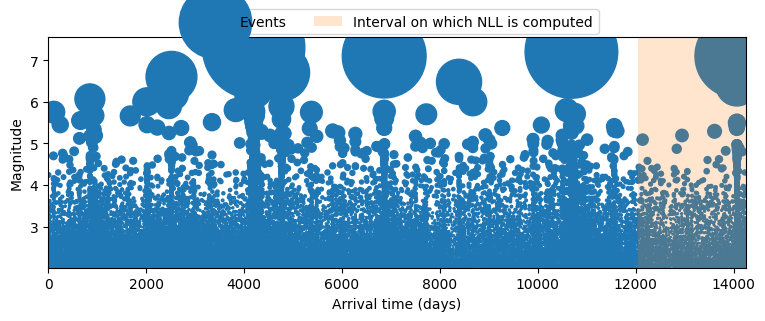

In [86]:
from src.utils.visualization import visualize_sequence
test_seq = catalog_ds.test[0]
train_seq = catalog_ds.train[0]
visualize_sequence(test_seq, show_nll=True)

We would like to generate a 7-day forecast for the interval `[4000, 4007]`. For this, we select two subsequences:
- `past_seq`: Contains events from `[0, 4000]`, is used to condition the model
- `observed_seq`: Contains actually observed events from `[4000, 4007]`.

In [87]:
t_forecast = 13000 # 4000 13000
duration = 7  # 7 30
num_samples = 10000 # 10000

# Past events that we condition on
past_seq = test_seq.get_subsequence(0, t_forecast) #  3500
observed_seq = test_seq.get_subsequence(t_forecast, t_forecast + duration)
# t_forecast = 12000
# past_seq = train_seq.get_subsequence(0, t_forecast) #  3500
# observed_seq = train_seq.get_subsequence(t_forecast, t_forecast + duration)

## Generate the forecast

In [88]:
past_seq

Sequence(
  inter_times: [115606],
  arrival_times: [115605],
  t_start: 0.0,
  t_end: 13000.0,
  t_nll_start: 12053.0,
  mag: [115605]
)

In [89]:
past_batch = src.data.Batch.from_list([past_seq])
# print(past_batch.inter_times)
print(past_batch.arrival_times.shape)
print(past_batch.mag.shape)
print(past_batch.input_mask.shape)

torch.Size([1, 115606])
torch.Size([1, 115606])
torch.Size([1, 115606])


In [90]:
torch.mean(past_batch.inter_times)

tensor(0.1125)

In [91]:
if torch.cuda.is_available():
    model.to('cuda:0')
    past_seq.to('cuda:0')

In [92]:
past_seq.float()

Sequence(
  inter_times: [115606],
  arrival_times: [115605],
  t_start: 0.0,
  t_end: 13000.0,
  t_nll_start: 12053.0,
  mag: [115605]
)

In [93]:
# torch.backends.cudnn.enabled = False

In [94]:
set_seed(3) 
model.eval()  # Set the model to evaluation mode

all_forecasts = []
samples_per_batch = 10000
for _ in range(num_samples // samples_per_batch):
    # forecast = model.sample_with_cache(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True, max_sample_len=2000)
    all_forecasts.extend(forecast)

`forecast` is a list, where each element is a `eq.data.Sequence` that represents a possible continuation of the catalog over the interval `[4000, 4007]`.

With the following function, we
- visualize 10 randomly chosen trajectories as a counting process
- plot the distribution of the total # of events in the forecast interval

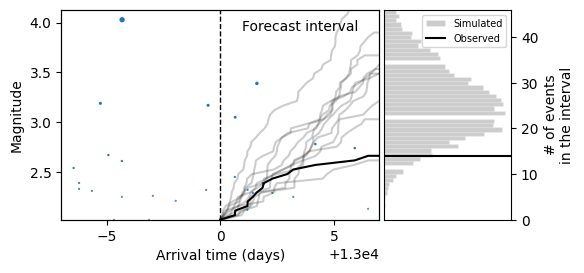

In [95]:
src.utils.visualization.visualize_trajectories(test_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.png")
# src.utils.visualization.visualize_trajectories(train_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.png")

In [96]:
from src.utils.catalog_tests import magnitude_test_from_counts,compute_magnitude_distribution,run_magnitude_test_result,run_number_test_result

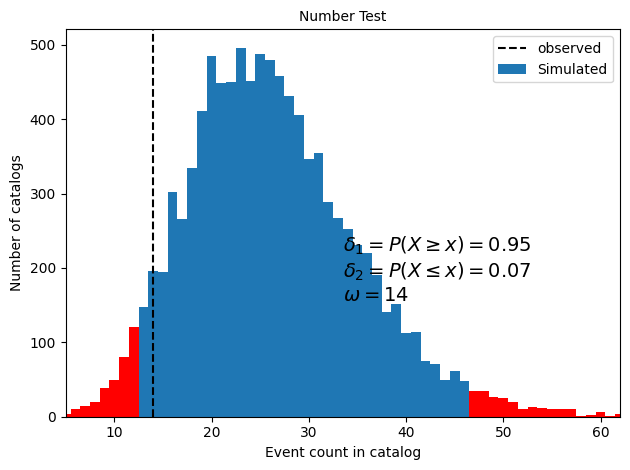

In [97]:
number_test_result = run_number_test_result(
    event_counts=[len(fc) for fc in all_forecasts],
    obs_count=len(observed_seq),                   
    min_mw=catalog_ds.metadata['mag_completeness'],
    obs_name='observed',
    sim_name='Simulated',
    plot=False
)
number_test_result.plot()
plt.savefig(checkpoint_dir/'n_test.png')

In [98]:
config_dict = {
    'min_mw': catalog_ds.metadata['mag_completeness'],
    'max_mw': 5,
    'dmw': 0.01
}

magnitude_bins, distribution = compute_magnitude_distribution(
    forecast[0].mag.cpu().numpy(), 
   **config_dict
)

In [99]:
get_counts = functools.partial(compute_magnitude_distribution, **config_dict)
result_dict = magnitude_test_from_counts(
    observed_catalog=observed_seq,
    forecast_catalogs=all_forecasts,
    get_counts=lambda cat: get_counts(np.asarray(cat.mag.cpu())),
    verbose=False
)


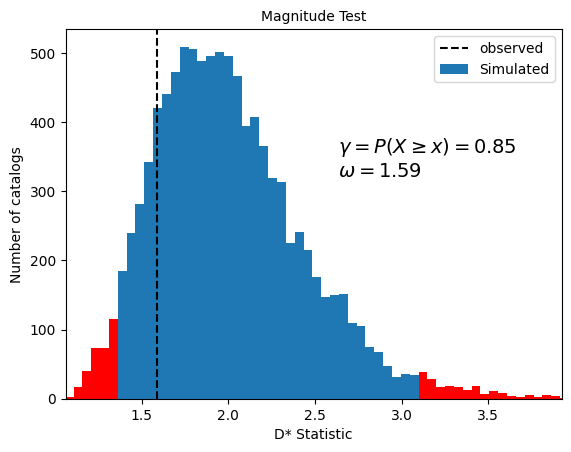

In [100]:
magnitude_test_result = run_magnitude_test_result(
    result_dict=result_dict,
    obs_catalog_repr='obs',
   obs_name='observed',
    sim_name='Simulated',
    plot=False
)
magnitude_test_result.plot()
plt.savefig(checkpoint_dir/'m_test.png')

In [101]:
def save_image(path, arr):
    arr = np.asarray(arr)
    if arr.dtype != np.uint8:
        arr = (255 * (arr - arr.min()) / (arr.max() - arr.min())).astype(np.uint8)
    plt.imsave(path, arr)

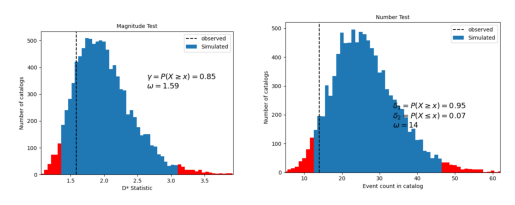

In [102]:
img1 = plt.imread(checkpoint_dir/'m_test.png')
img2 = plt.imread(checkpoint_dir/'n_test.png')

# 横向拼接
merged = np.concatenate((img1, img2), axis=1)

plt.imshow(merged)
plt.axis("off")
plt.show()

save_image(checkpoint_dir/"tests.png", merged)
